# Assignment 3 — Task 1
## Dataset Analysis and Statistical Exploration of SentiUrdu-1M

**Course:** CSC-355 Natural Language Processing
**Students:** Raqib Hayat (NUM-BSCS-2022-40), Abu Bakar (NUM-BSCS-2022-41)
**Dataset:** [SentiUrdu-1M](https://data.mendeley.com/datasets/rz3xg97rm5/1) — ~1,048,000 weakly-labelled Urdu tweets

This notebook goes well beyond the basic exploration from Milestone 1. It performs:

1. **Dataset overview** — shape, dtypes, memory footprint, missing values, duplicates.
2. **Label distribution** — emotion (`Category`) and derived 3-class sentiment.
3. **Text statistics** — token / character length distributions, per-class boxplots.
4. **Token frequency** — top-50 tokens overall and per class, Zipf's law.
5. **Emoji and noise** — emoji frequency, URL/mention/hashtag share, code-mixing,
   label-leakage correlation.
6. **Preprocessing impact** — before vs after length, vocabulary reduction, empty-tweet rate.
7. **Dataset suitability discussion** — strengths, limitations, decisions, expected biases.

All figures are saved to `outputs/figures/`. The notebook is idempotent: cached
intermediate Parquet files in `outputs/cache/` are reused on subsequent runs.


## 0 — Setup


In [1]:
# --- runtime / path setup -------------------------------------------------
import os, sys, warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("PYTHONIOENCODING", "utf-8")
ROOT = os.path.dirname(os.path.abspath("__file__"))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import config
import preprocessing as pp
from config import (
    DATA_CSV, FIG_DIR, MODEL_DIR, RESULTS_DIR, CACHE_DIR, EMBED_DIR,
    SEED, set_seed,
    EMOTION_LABELS, SENTIMENT_LABELS,
    EMOTION_TO_SENTIMENT,
)
set_seed(SEED)
print(f"seed={SEED}   data csv: {DATA_CSV.exists()}")


seed=42   data csv: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_theme(context="notebook", style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = config.FIG_DPI
plt.rcParams["savefig.dpi"] = config.FIG_DPI
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

FIG_EXT = config.FIG_FORMAT

def savefig(name: str, fig=None, **kw):
    fig = fig or plt.gcf()
    out = FIG_DIR / f"{name}.{FIG_EXT}"
    fig.tight_layout()
    fig.savefig(out, bbox_inches="tight", **kw)
    print(f"  ↳ saved {out.name}")


## 1 — Dataset Overview & Structure


In [3]:
%%time
# Loading the CSV is much faster than the XLSX (≈ 6× speedup).
df = pd.read_csv(DATA_CSV, dtype=str, keep_default_na=False, na_values=[""])
df["Id"] = pd.to_numeric(df["Id"], errors="coerce").astype("Int64")
print(f"Shape : {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)


Shape : (1048000, 4)
Memory: 548.6 MB
CPU times: total: 2.7 s
Wall time: 2.73 s


,Id,Text,Emotions,Category
0,1313165582020349952,.Assalam Alikum 🦋😊 اے ایمان والو میرے دشم...,"['SMILING FACE WITH SMILING EYES , 0.644']",Joy
1,1314653586509488128,- '' 🍀 🌾 🌴 '' - ﺍﮬﺪِﻧَﺎﻟﺼِّﺮَﺍﻁَ ﺍَﻟﻤُﺴﺘَﻘِﯿﻢ...,"['HEAVY BLACK HEART , 0.746', 'SPARKLES , 0.35...",NaN
2,1311404383071067904,💕 میں نہیں کرتی اُس کا ذکر کسی تیسرے کے سات...,"['TWO HEARTS , 0.632']",NaN


In [4]:
print("Dtypes")
print(df.dtypes, "\n")
print("Missing values per column")
print(df.isna().sum())
print("\nUnique counts")
for c in df.columns:
    print(f"  {c:>10}: {df[c].nunique(dropna=True)} unique")


Dtypes
Id           Int64
Text        object
Emotions    object
Category    object
dtype: object 

Missing values per column
Id               0
Text             0
Emotions         0
Category    514571
dtype: int64

Unique counts
          Id: 1039959 unique
        Text: 1016696 unique
    Emotions: 44552 unique
    Category: 298 unique


In [5]:
# Duplicate analysis (on raw text — preprocessing collapses many near-dupes).
dup_text  = df.duplicated(subset=["Text"]).sum()
dup_full  = df.duplicated().sum()
print(f"Duplicate raw Text rows : {dup_text:>8,}  ({dup_text/len(df)*100:.2f}%)")
print(f"Duplicate full rows     : {dup_full:>8,}  ({dup_full/len(df)*100:.2f}%)")


Duplicate raw Text rows :   31,304  (2.99%)
Duplicate full rows     :      386  (0.04%)


  ↳ saved fig01_missing_pattern.png


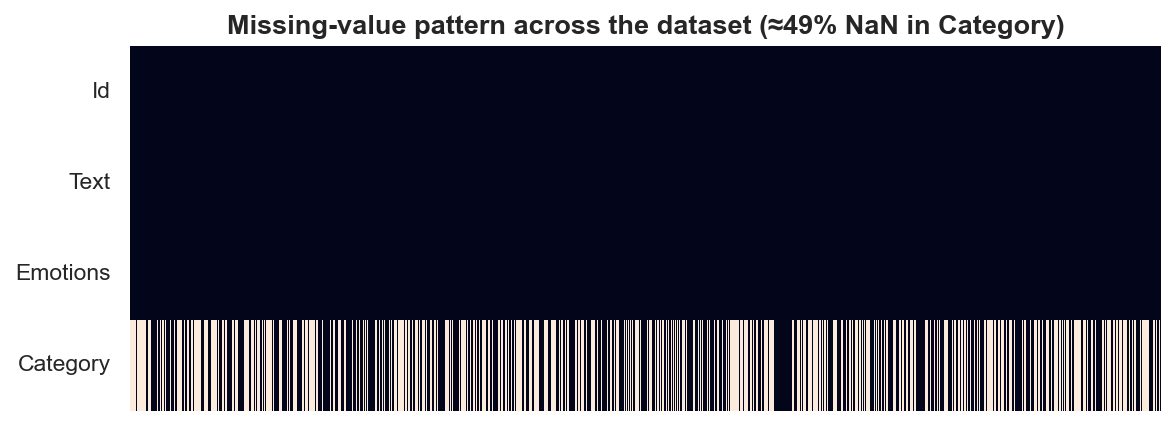

In [6]:
# Missing-data heatmap
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(df.isna().T, cbar=False, ax=ax, yticklabels=df.columns)
ax.set_xticks([])
ax.set_title("Missing-value pattern across the dataset (≈49% NaN in Category)")
savefig("fig01_missing_pattern")
plt.show()


## 2 — Label Distribution Analysis


In [7]:
# Apply the project's preprocessing pipeline once and cache the result.
cache = CACHE_DIR / "df_clean.parquet"
if cache.exists():
    df_clean = pd.read_parquet(cache)
    print(f"Loaded cached cleaned dataframe: {df_clean.shape}")
else:
    df_clean = df.copy()
    df_clean["clean_text"]    = pp.preprocess_series(df_clean["Text"])
    df_clean["sentiment"]     = df_clean.apply(pp.build_sentiment_label, axis=1)
    df_clean["emotion"]       = df_clean["Category"].map(pp.majority_emotion)
    df_clean["n_tokens_raw"]  = df_clean["Text"].fillna("").str.split().str.len()
    df_clean["n_tokens"]      = df_clean["clean_text"].str.split().str.len()
    df_clean["n_chars_raw"]   = df_clean["Text"].fillna("").str.len()
    df_clean["n_chars"]       = df_clean["clean_text"].str.len()
    df_clean.to_parquet(cache, index=False)
    print(f"Cleaned and cached: {df_clean.shape}")
df_clean.head(3)


Loaded cached cleaned dataframe: (1048000, 11)


,Id,Text,Emotions,Category,clean_text,sentiment,emotion,n_tokens_raw,n_tokens,n_chars_raw,n_chars
0,1313165582020349952,.Assalam Alikum 🦋😊 اے ایمان والو میرے دشم...,"['SMILING FACE WITH SMILING EYES , 0.644']",Joy,Assalam Alikum اے ایمان والو میرے دشمنوں اور ا...,Positive,Joy,23,22,113,104
1,1314653586509488128,- '' 🍀 🌾 🌴 '' - ﺍﮬﺪِﻧَﺎﻟﺼِّﺮَﺍﻁَ ﺍَﻟﻤُﺴﺘَﻘِﯿﻢ...,"['HEAVY BLACK HEART , 0.746', 'SPARKLES , 0.35...",None,ﺍﮬﺪِﻧَﺎﻟﺼِّﺮَﺍﻁَ ﺍَﻟﻤُﺴﺘَﻘِﯿﻢَ ﺍﮮ ﻣﯿﺮﮮ ﺭﺏ ﻣﺠﮭﮯ...,None,None,24,16,130,101
2,1311404383071067904,💕 میں نہیں کرتی اُس کا ذکر کسی تیسرے کے سات...,"['TWO HEARTS , 0.632']",None,میں نہیں کرتی اُس کا ذکر کسی تیسرے کے ساتھ اُس...,None,None,23,21,99,89


Emotion counts (Category column):
emotion
Joy         459728
Sad          50417
Angry         2802
Fear          1847
Disgust      17083
Surprise      1552
Name: count, dtype: int64

Imbalance ratio (max/min) = 296.22×
  ↳ saved fig02_emotion_distribution.png


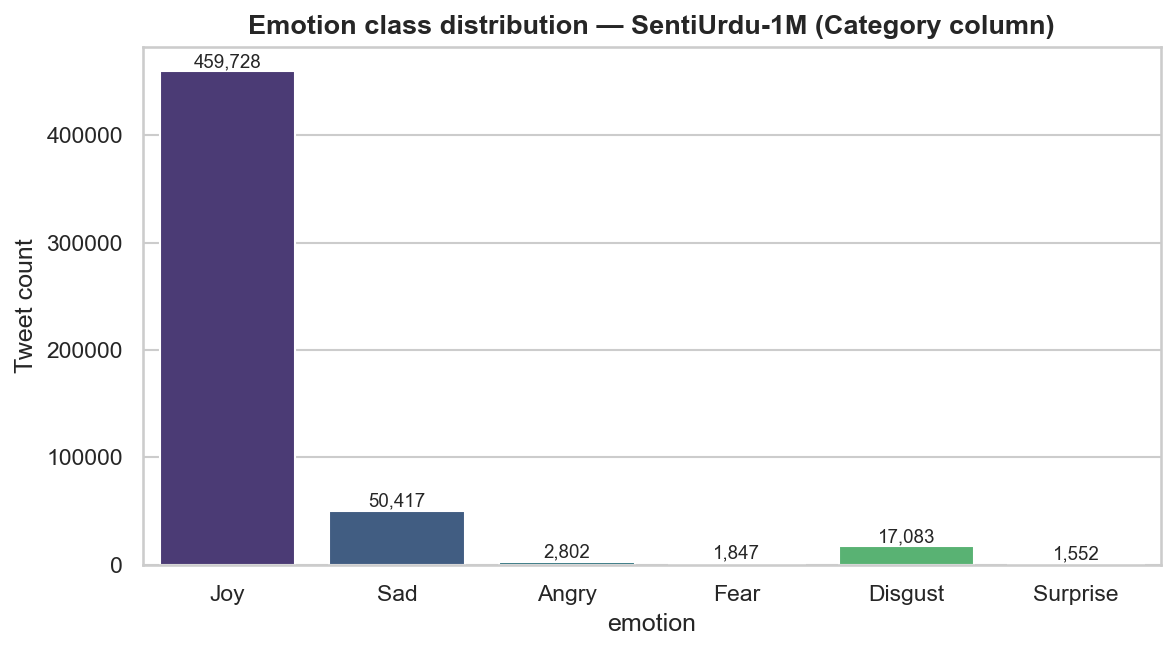

In [8]:
# 2.1 Emotion label distribution
ec = df_clean["emotion"].value_counts(dropna=True).reindex(EMOTION_LABELS).fillna(0).astype(int)
print("Emotion counts (Category column):")
print(ec)
imbal = ec.max() / max(ec.min(), 1)
print(f"\nImbalance ratio (max/min) = {imbal:.2f}×")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=ec.index, y=ec.values, ax=ax, palette="viridis")
ax.set_title("Emotion class distribution — SentiUrdu-1M (Category column)")
ax.set_ylabel("Tweet count")
for i, v in enumerate(ec.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
savefig("fig02_emotion_distribution")
plt.show()


Derived sentiment counts (full dataset; 514,571 unmapped/NaN dropped):
sentiment
Negative     72149
Neutral       1552
Positive    459728
Name: count, dtype: int64
  ↳ saved fig03_sentiment_distribution.png


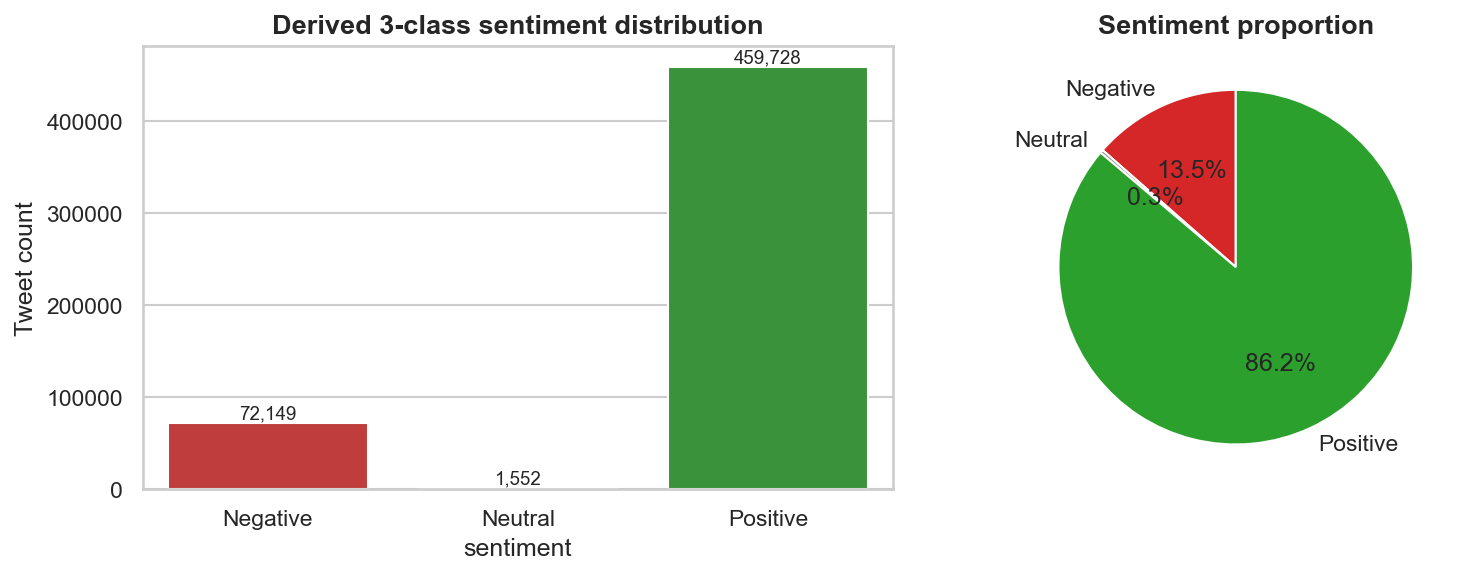

In [9]:
# 2.2 Derived 3-class sentiment distribution
sc = df_clean["sentiment"].value_counts(dropna=True).reindex(SENTIMENT_LABELS).fillna(0).astype(int)
n_unlabelled = df_clean["sentiment"].isna().sum()
print(f"Derived sentiment counts (full dataset; {n_unlabelled:,} unmapped/NaN dropped):")
print(sc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=sc.index, y=sc.values, ax=axes[0], palette=["#d62728", "#7f7f7f", "#2ca02c"])
axes[0].set_title("Derived 3-class sentiment distribution")
axes[0].set_ylabel("Tweet count")
for i, v in enumerate(sc.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

axes[1].pie(sc.values, labels=sc.index, autopct="%1.1f%%",
            colors=["#d62728", "#7f7f7f", "#2ca02c"], startangle=90)
axes[1].set_title("Sentiment proportion")
savefig("fig03_sentiment_distribution")
plt.show()


sentiment  Negative  Neutral  Positive
emotion                               
Joy               0        0    459728
Sad           50417        0         0
Angry          2802        0         0
Fear           1847        0         0
Disgust       17083        0         0
Surprise          0     1552         0
  ↳ saved fig04_emotion_vs_sentiment.png


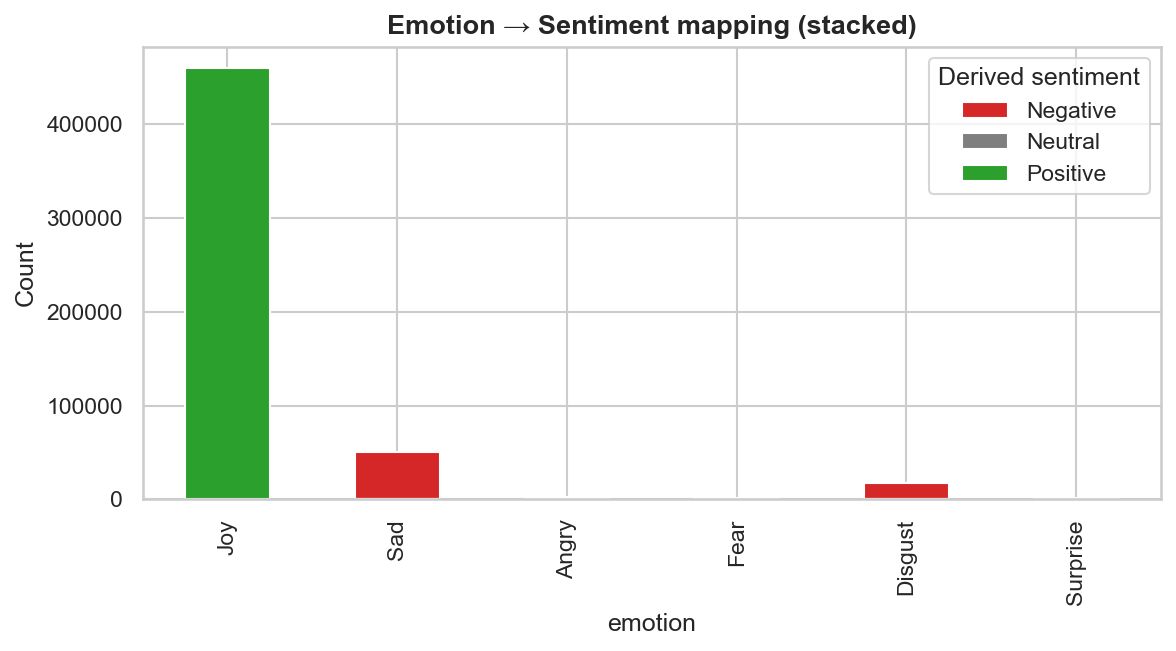

In [10]:
# 2.3 Stacked comparison: emotion × derived sentiment
crosstab = pd.crosstab(df_clean["emotion"], df_clean["sentiment"]).reindex(
    index=EMOTION_LABELS, columns=SENTIMENT_LABELS, fill_value=0
)
print(crosstab)

fig, ax = plt.subplots(figsize=(8, 4.5))
crosstab.plot(kind="bar", stacked=True, ax=ax,
              color=["#d62728", "#7f7f7f", "#2ca02c"])
ax.set_title("Emotion → Sentiment mapping (stacked)")
ax.set_ylabel("Count")
ax.legend(title="Derived sentiment")
savefig("fig04_emotion_vs_sentiment")
plt.show()


## 3 — Text Statistics


In [11]:
# Length statistics (cleaned text)
summary = df_clean[["n_tokens", "n_chars", "n_tokens_raw", "n_chars_raw"]].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)
summary


,n_tokens,n_chars,n_tokens_raw,n_chars_raw
count,1.048000e+06,1.048000e+06,1.048000e+06,1.048000e+06
mean,1.500410e+01,6.811048e+01,1.601123e+01,7.374899e+01
std,1.188746e+01,5.495630e+01,1.208744e+01,5.653875e+01
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
50%,1.200000e+01,5.500000e+01,1.300000e+01,6.000000e+01
90%,2.900000e+01,1.330000e+02,3.000000e+01,1.410000e+02
95%,4.000000e+01,1.880000e+02,4.200000e+01,1.980000e+02
99%,5.800000e+01,2.630000e+02,5.900000e+01,2.710000e+02
max,1.010000e+02,2.930000e+02,1.130000e+02,8.120000e+02


  ↳ saved fig05_length_histograms.png


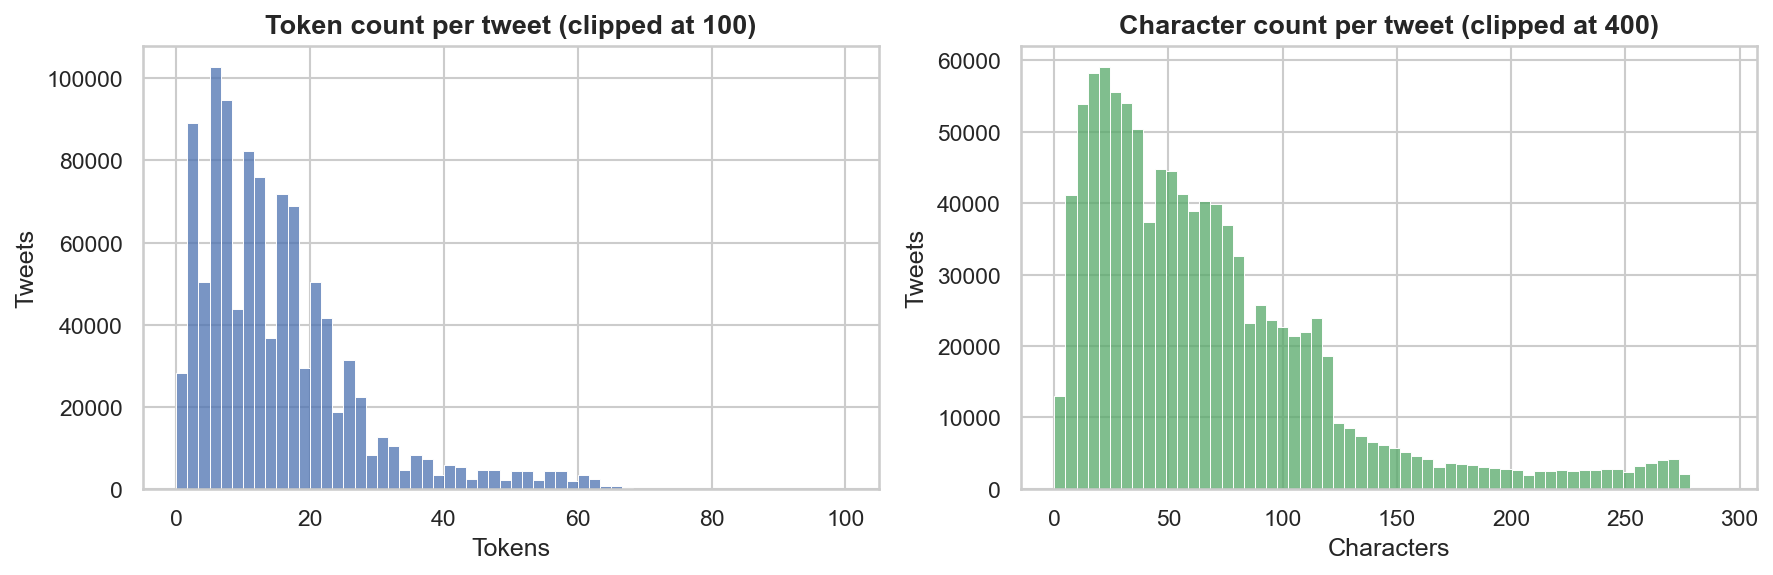

In [12]:
# Histograms of token/character counts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean["n_tokens"].clip(upper=100), bins=60, ax=axes[0], color="#4c72b0")
axes[0].set_title("Token count per tweet (clipped at 100)")
axes[0].set_xlabel("Tokens"); axes[0].set_ylabel("Tweets")

sns.histplot(df_clean["n_chars"].clip(upper=400), bins=60, ax=axes[1], color="#55a868")
axes[1].set_title("Character count per tweet (clipped at 400)")
axes[1].set_xlabel("Characters"); axes[1].set_ylabel("Tweets")
savefig("fig05_length_histograms")
plt.show()


  ↳ saved fig06_tokens_by_emotion_box.png


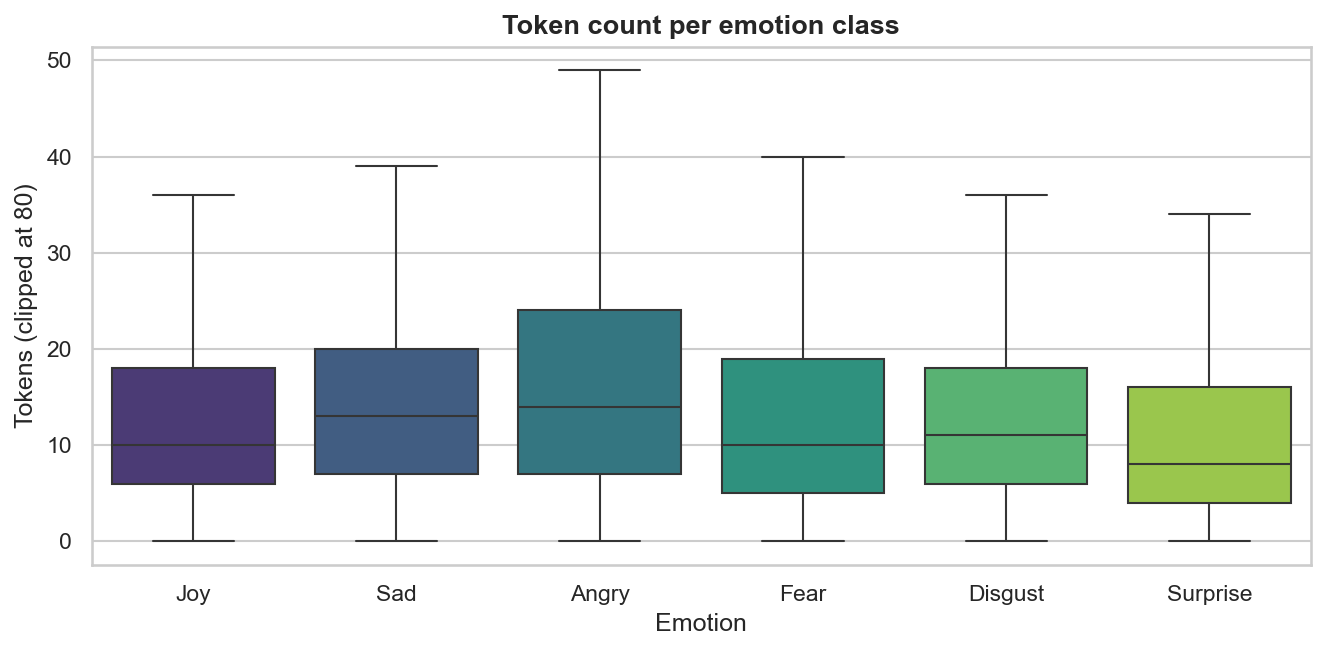

In [13]:
# Boxplot — text length by emotion class
fig, ax = plt.subplots(figsize=(9, 4.5))
order = EMOTION_LABELS
sub = df_clean.dropna(subset=["emotion"]).copy()
sub["n_tokens_clip"] = sub["n_tokens"].clip(upper=80)
sns.boxplot(data=sub, x="emotion", y="n_tokens_clip", order=order,
            showfliers=False, palette="viridis", ax=ax)
ax.set_title("Token count per emotion class")
ax.set_xlabel("Emotion"); ax.set_ylabel("Tokens (clipped at 80)")
savefig("fig06_tokens_by_emotion_box")
plt.show()


In [14]:
# Per-class summary table
per_class = sub.groupby("emotion")["n_tokens"].agg(
    n="size", mean="mean", median="median", p95=lambda s: s.quantile(0.95)
).reindex(order)
per_class


,n,mean,median,p95
emotion,,,,
Joy,459728,13.466776,10.0,35.0
Sad,50417,15.605649,13.0,42.0
Angry,2802,17.663812,14.0,48.0
Fear,1847,13.981050,10.0,44.7
Disgust,17083,13.539308,11.0,33.0
Surprise,1552,11.146263,8.0,31.0


## 4 — Token Frequency Analysis


In [15]:
# Build global token counter (skip empty rows)
tokens_cache = CACHE_DIR / "token_counter.json"
import json
if tokens_cache.exists():
    with open(tokens_cache, "r", encoding="utf-8") as f:
        counter_dict = json.load(f)
    counter = Counter(counter_dict)
    print(f"Loaded cached token counter: {len(counter):,} types")
else:
    counter = Counter()
    for tok_list in df_clean["clean_text"].dropna().str.split():
        counter.update(tok_list)
    with open(tokens_cache, "w", encoding="utf-8") as f:
        json.dump(dict(counter.most_common(200_000)), f, ensure_ascii=False)
    print(f"Built and cached token counter: {len(counter):,} types")

top50 = counter.most_common(50)
print("Top-10 tokens (after preprocessing):")
for t, c in top50[:10]:
    print(f"  {t:>15}  {c:,}")


Loaded cached token counter: 200,000 types
Top-10 tokens (after preprocessing):
               ہے  418,618
              میں  317,839
               کے  282,364
               کی  270,062
               سے  247,690
               کو  213,265
               تو  205,895
             نہیں  197,895
               کا  186,264
              اور  184,672


  ↳ saved fig07_top50_tokens.png


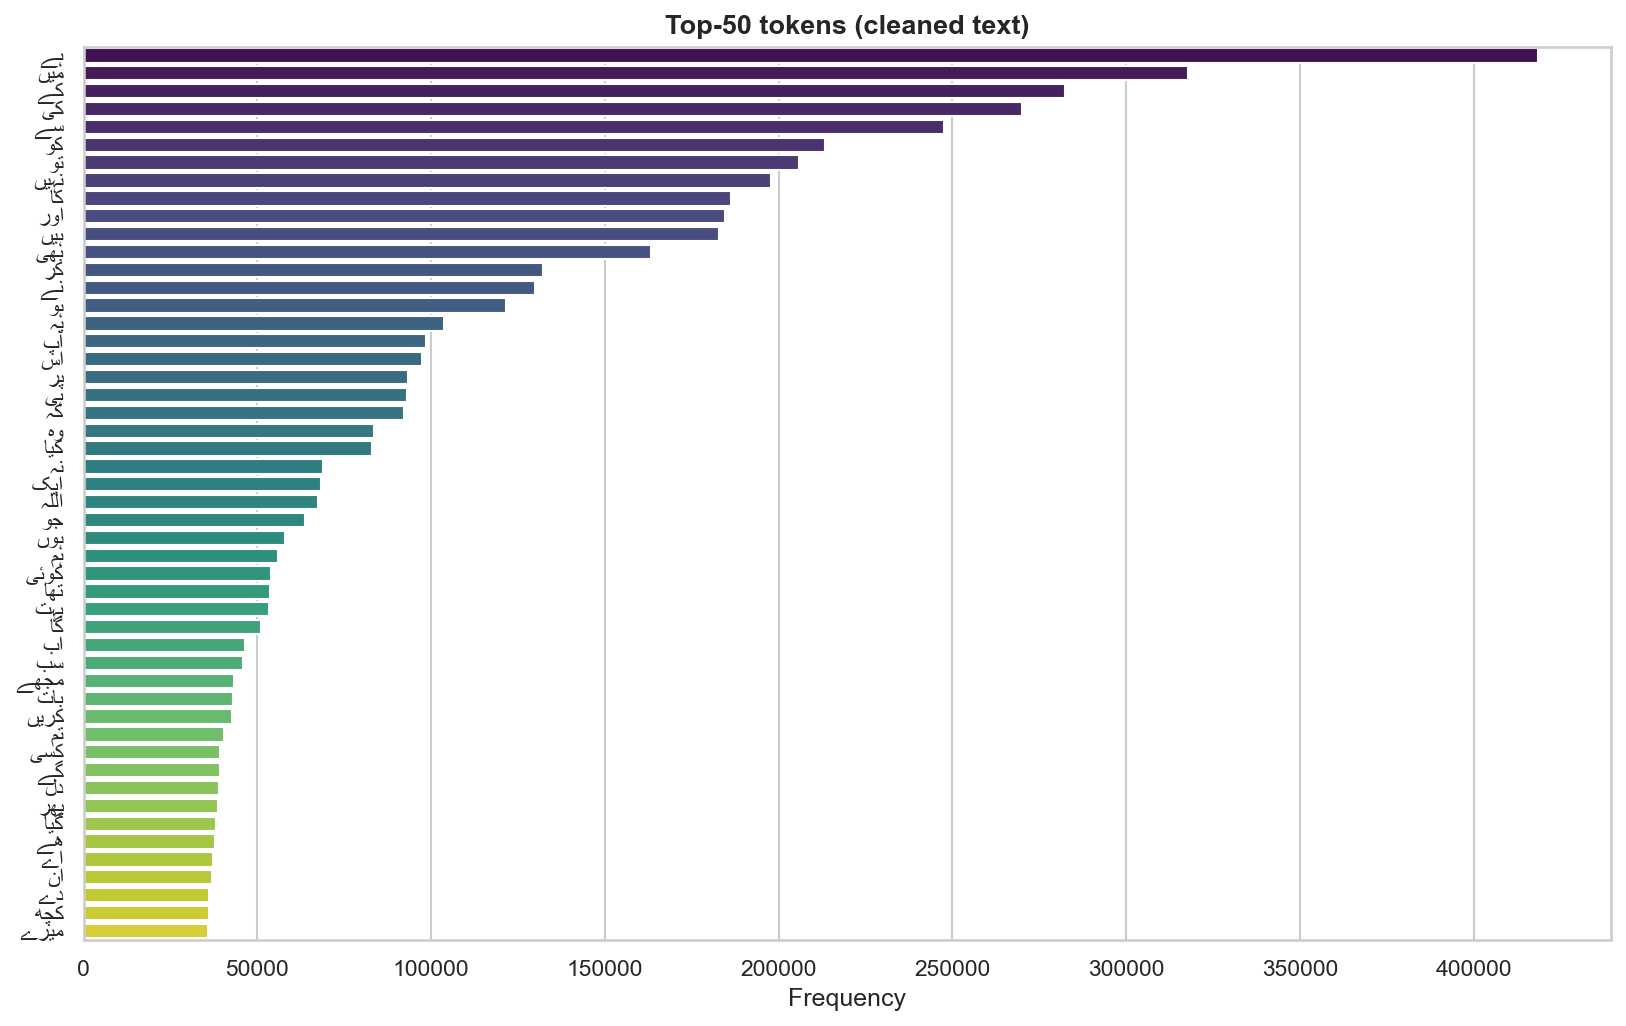

In [16]:
# Top-50 token bar chart
import arabic_reshaper
from bidi.algorithm import get_display

labels = [get_display(arabic_reshaper.reshape(t)) for t, _ in top50]
counts = [c for _, c in top50]

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(x=counts, y=labels, ax=ax, palette="viridis")
ax.set_title("Top-50 tokens (cleaned text)")
ax.set_xlabel("Frequency"); ax.set_ylabel("")
savefig("fig07_top50_tokens")
plt.show()


  ↳ saved fig08_zipf.png


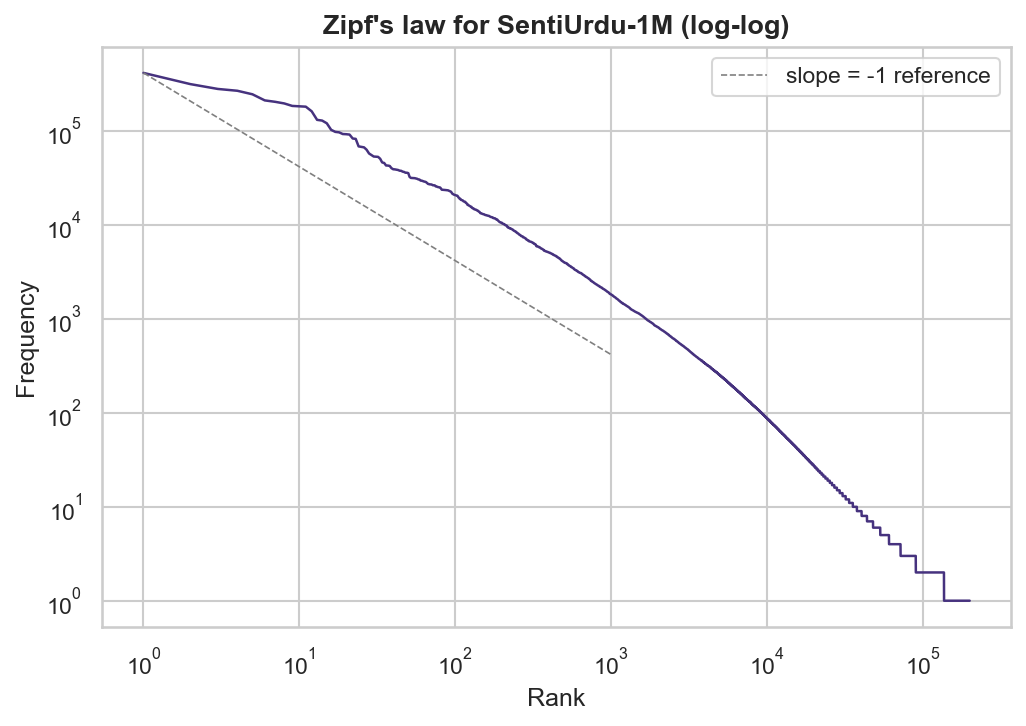

Vocabulary size (cleaned): 200,000
Tokens appearing only once: 63,267 (31.6%)


In [17]:
# Zipf's law — log-log plot of rank vs frequency
freqs = np.array(sorted(counter.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ranks, freqs, lw=1.2)
ax.set_title("Zipf's law for SentiUrdu-1M (log-log)")
ax.set_xlabel("Rank"); ax.set_ylabel("Frequency")
# Reference slope -1
ax.loglog(ranks[:1000], freqs[0] / ranks[:1000], "--", color="gray", lw=0.8,
          label="slope = -1 reference")
ax.legend()
savefig("fig08_zipf")
plt.show()

print(f"Vocabulary size (cleaned): {len(counter):,}")
print(f"Tokens appearing only once: {sum(1 for v in counter.values() if v == 1):,} ({sum(1 for v in counter.values() if v == 1)/len(counter)*100:.1f}%)")


  ↳ saved fig09_top15_per_emotion.png


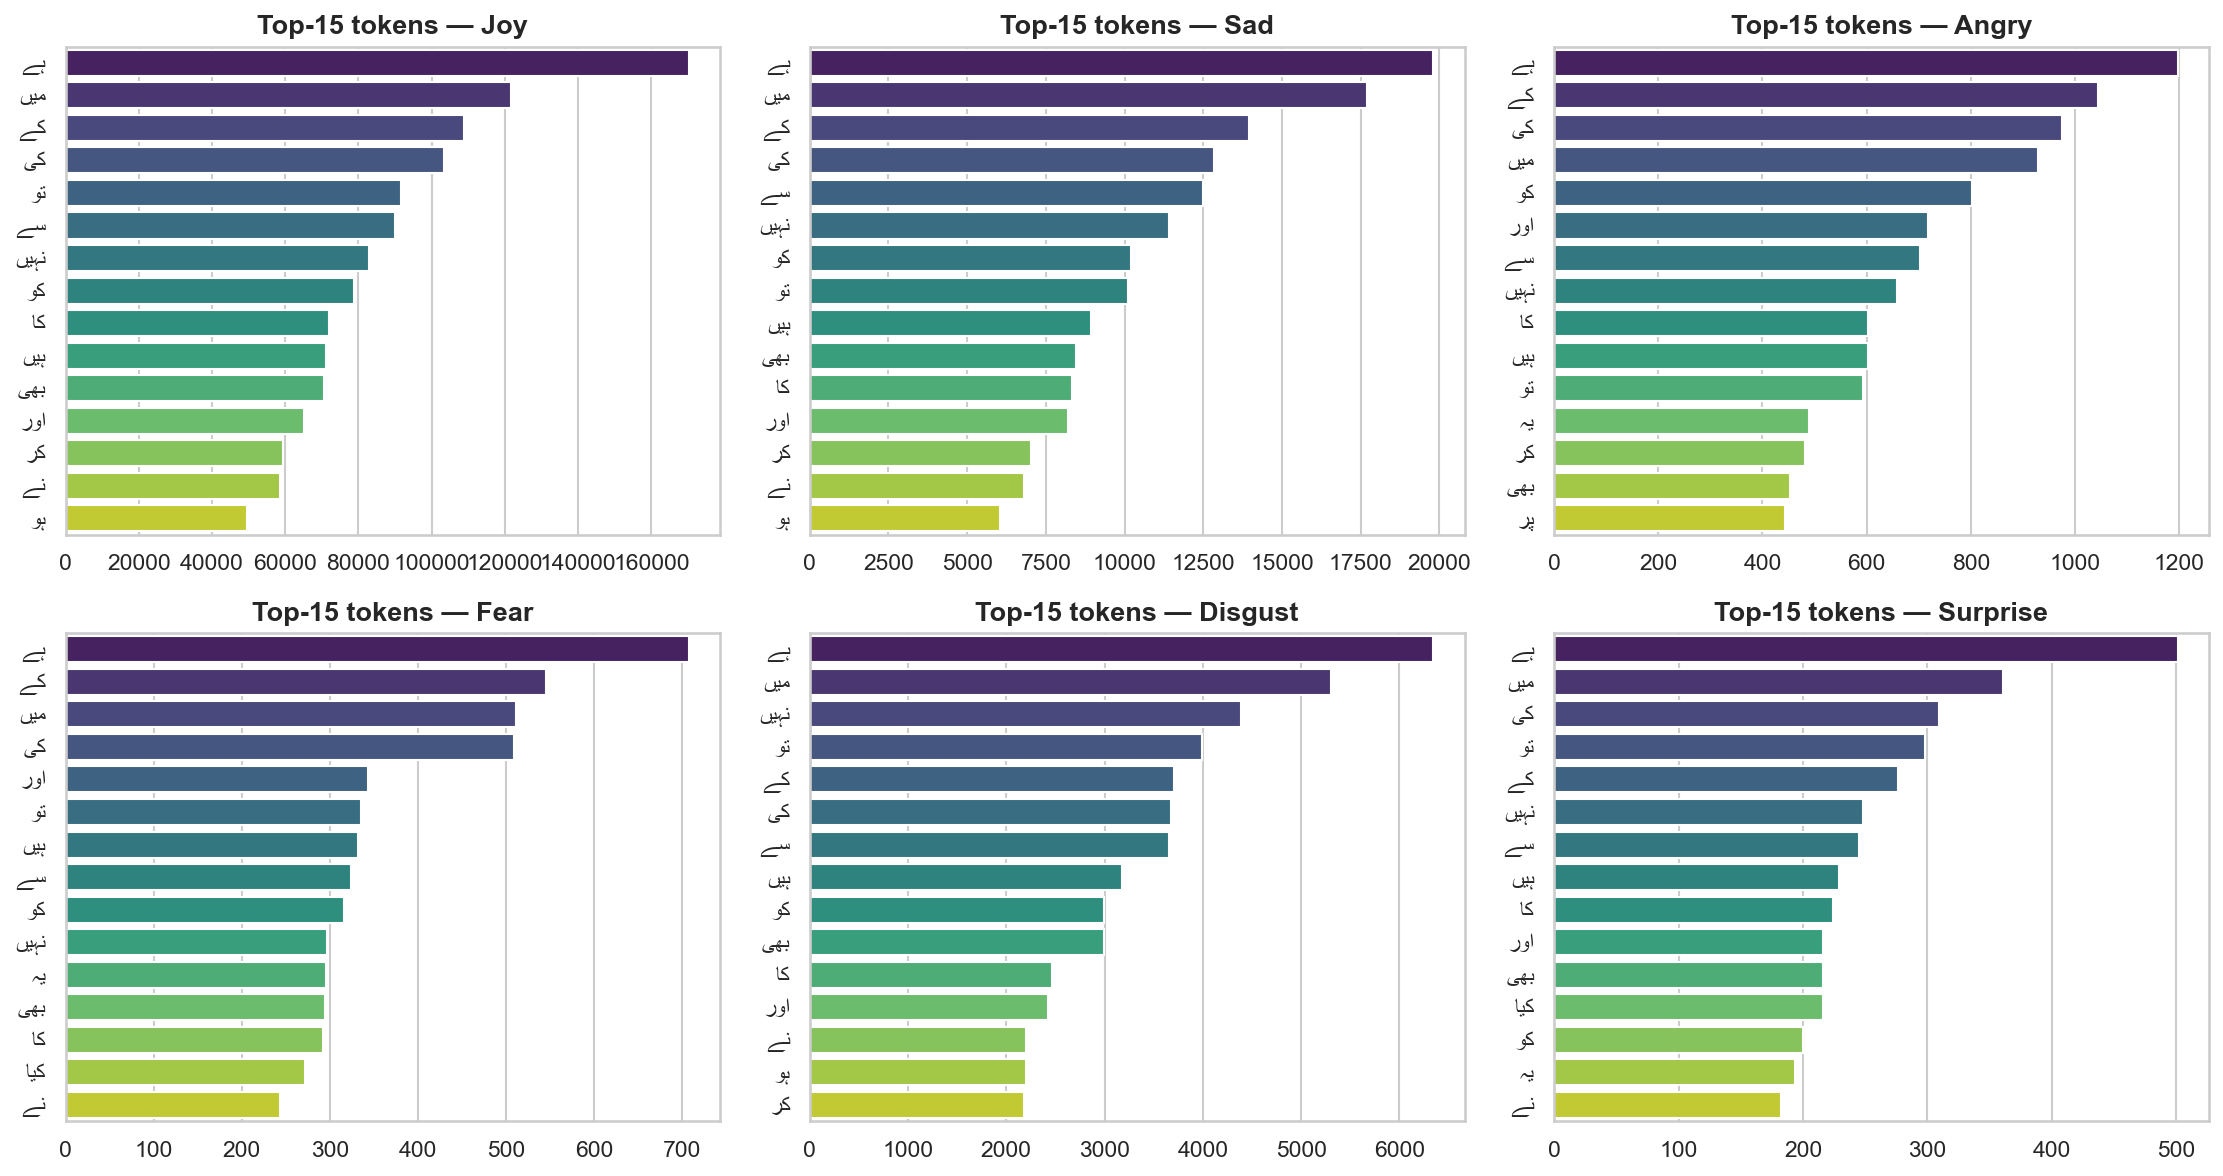

In [18]:
# Per-class top-15 tokens
per_class_top = {}
for cls in EMOTION_LABELS:
    sub_tok = Counter()
    rows = df_clean.loc[df_clean["emotion"] == cls, "clean_text"].dropna()
    for toks in rows.str.split():
        sub_tok.update(toks)
    per_class_top[cls] = sub_tok.most_common(15)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, cls in zip(axes.flat, EMOTION_LABELS):
    items = per_class_top[cls]
    labs = [get_display(arabic_reshaper.reshape(t)) for t, _ in items]
    vals = [c for _, c in items]
    sns.barplot(x=vals, y=labs, ax=ax, palette="viridis")
    ax.set_title(f"Top-15 tokens — {cls}")
    ax.set_xlabel(""); ax.set_ylabel("")
savefig("fig09_top15_per_emotion")
plt.show()


WordCloud font: C:/Windows/Fonts/Tahoma.ttf
  ↳ saved fig10_wordclouds.png


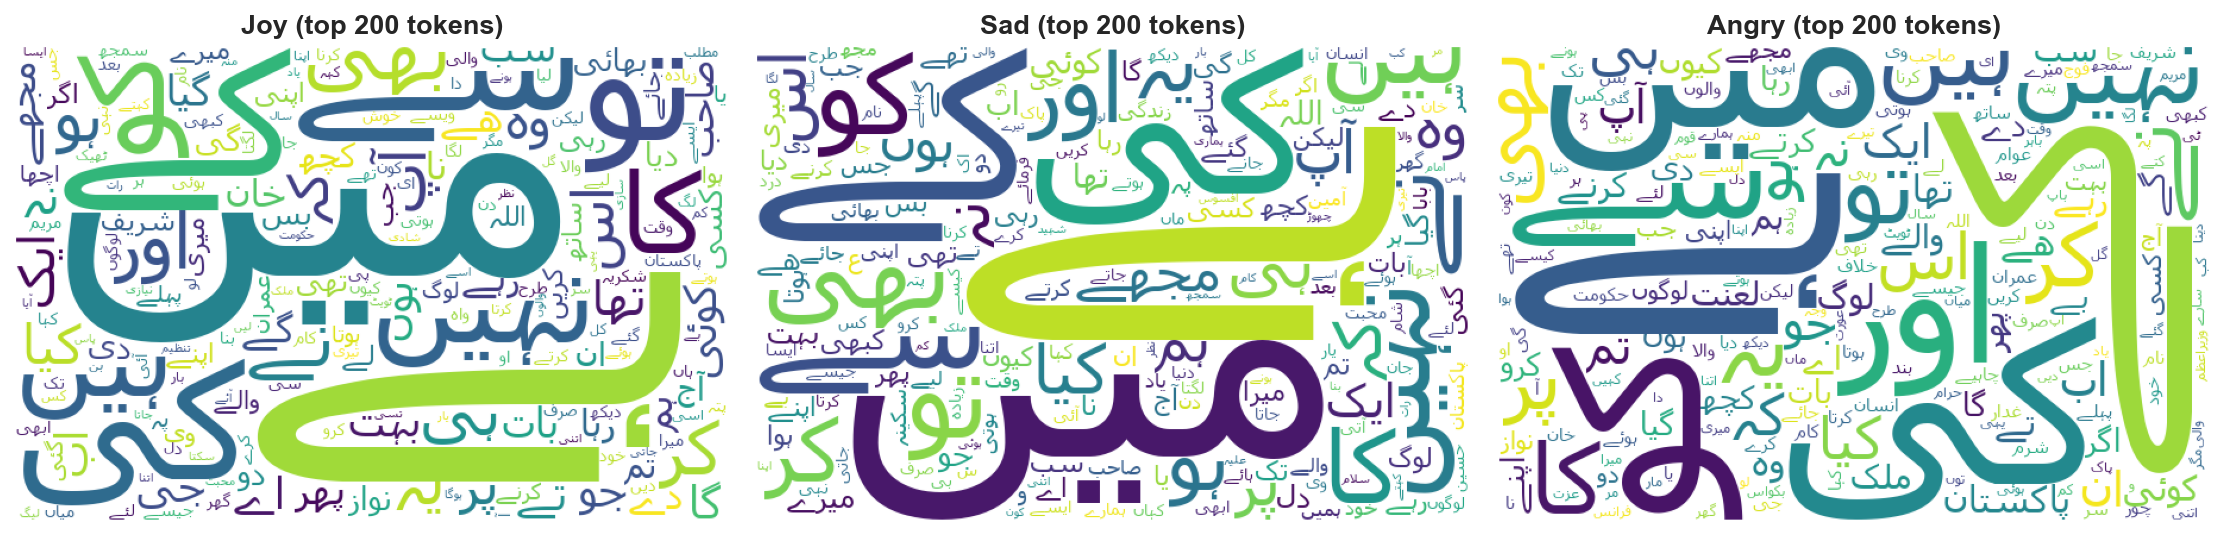

In [19]:
# Word clouds for three contrasting emotions
from wordcloud import WordCloud
font_path = None
# Try a few common Windows fonts that support Urdu glyphs.
for cand in [r"C:/Windows/Fonts/NafeesWeb.ttf",
             r"C:/Windows/Fonts/NafeesNastaleeq.ttf",
             r"C:/Windows/Fonts/JameelNooriNastaleeq.ttf",
             r"C:/Windows/Fonts/Tahoma.ttf",
             r"C:/Windows/Fonts/Arial.ttf"]:
    if Path(cand).exists():
        font_path = cand
        break
print("WordCloud font:", font_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, cls in zip(axes, ["Joy", "Sad", "Angry"]):
    sub_tok = Counter()
    rows = df_clean.loc[df_clean["emotion"] == cls, "clean_text"].dropna()
    for toks in rows.str.split():
        sub_tok.update(toks)
    # reshape for proper Arabic rendering inside the cloud
    reshaped = {get_display(arabic_reshaper.reshape(k)): v for k, v in sub_tok.most_common(200)}
    wc = WordCloud(font_path=font_path, width=600, height=400,
                   background_color="white", colormap="viridis").generate_from_frequencies(reshaped)
    ax.imshow(wc); ax.axis("off"); ax.set_title(f"{cls} (top 200 tokens)")
savefig("fig10_wordclouds")
plt.show()


## 5 — Emoji and Noise Analysis


Share of tweets containing each feature (200K random sample):
has_url          0.0 %
has_mention     2.05 %
has_hashtag     0.04 %
has_emoji      99.34 %
has_latin       9.29 %
dtype: object
  ↳ saved fig11_noise_features.png


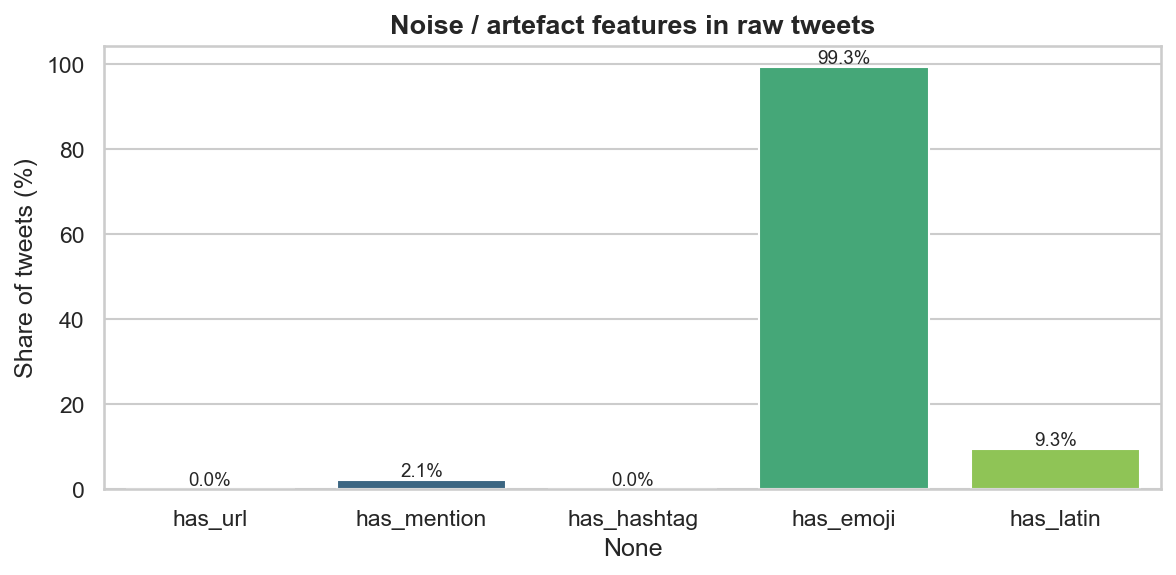

In [20]:
import re
import emoji as _emoji_lib

# Re-run a small (sampled) noise-feature audit so we don't iterate 1M rows twice
sample = df.sample(min(200_000, len(df)), random_state=SEED).copy()

def has_emoji(s):  return any(c for c in s if c in _emoji_lib.EMOJI_DATA) if isinstance(s, str) else False
sample["has_url"]     = sample["Text"].fillna("").str.contains(r"https?://|www\.", regex=True)
sample["has_mention"] = sample["Text"].fillna("").str.contains(r"@\w+", regex=True)
sample["has_hashtag"] = sample["Text"].fillna("").str.contains(r"#\S+", regex=True)
sample["has_emoji"]   = sample["Text"].apply(has_emoji)
sample["has_latin"]   = sample["Text"].fillna("").str.contains(r"[A-Za-z]{3,}", regex=True)

noise = sample[["has_url","has_mention","has_hashtag","has_emoji","has_latin"]].mean() * 100
print("Share of tweets containing each feature (200K random sample):")
print(noise.round(2).astype(str) + " %")

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=noise.index, y=noise.values, ax=ax, palette="viridis")
for i, v in enumerate(noise.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("Noise / artefact features in raw tweets")
ax.set_ylabel("Share of tweets (%)")
savefig("fig11_noise_features")
plt.show()


Top-20 emojis (300K sample): [('😂', 166299), ('❤', 37339), ('😜', 22445), ('😁', 18352), ('🌹', 18284), ('💔', 18219), ('🙏', 14514), ('😍', 14277), ('😭', 12181), ('🔥', 10511), ('😅', 9097), ('😝', 8925), ('😊', 8386), ('👇', 7990), ('💕', 7897), ('😆', 7405), ('♥', 7339), ('😀', 7184), ('✌', 7105), ('💞', 6942)]
  ↳ saved fig12_top_emojis.png


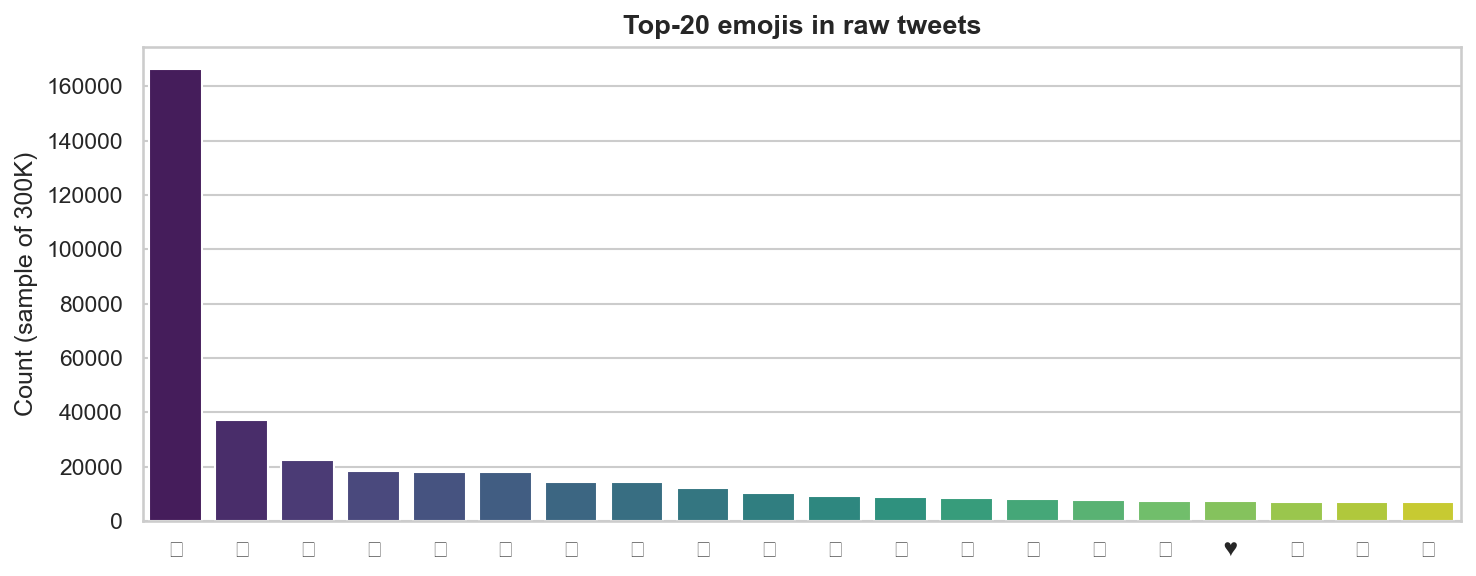

In [21]:
# Top-20 emoji frequency
emoji_counter = Counter()
for txt in df["Text"].dropna().sample(300_000, random_state=SEED):
    for ch in txt:
        if ch in _emoji_lib.EMOJI_DATA:
            emoji_counter[ch] += 1
top_em = emoji_counter.most_common(20)
print("Top-20 emojis (300K sample):", top_em)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=[e for e,_ in top_em], y=[c for _,c in top_em], ax=ax, palette="viridis")
ax.set_title("Top-20 emojis in raw tweets")
ax.set_ylabel("Count (sample of 300K)")
savefig("fig12_top_emojis")
plt.show()


  ↳ saved fig13_label_leakage_heatmap.png


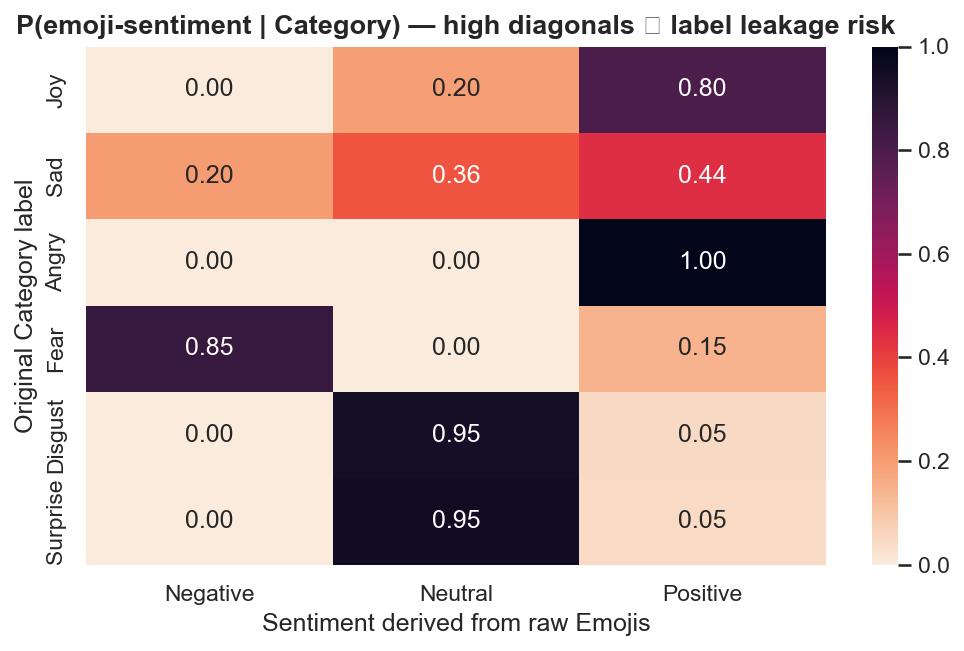

In [22]:
# Label-leakage diagnostic: emoji-derived sentiment vs Category-derived sentiment
leak = df_clean.dropna(subset=["emotion"]).copy()
leak["sent_from_emojis"] = leak["Emotions"].map(pp.derive_sentiment_from_emotions)
cm_leak = pd.crosstab(leak["emotion"], leak["sent_from_emojis"]).reindex(
    index=EMOTION_LABELS, columns=SENTIMENT_LABELS, fill_value=0
)
cm_leak_norm = cm_leak.div(cm_leak.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(cm_leak_norm, annot=True, fmt=".2f", cmap="rocket_r", ax=ax)
ax.set_title("P(emoji-sentiment | Category) — high diagonals ⇒ label leakage risk")
ax.set_xlabel("Sentiment derived from raw Emojis")
ax.set_ylabel("Original Category label")
savefig("fig13_label_leakage_heatmap")
plt.show()


## 6 — Preprocessing Impact


  ↳ saved fig14_length_before_after.png


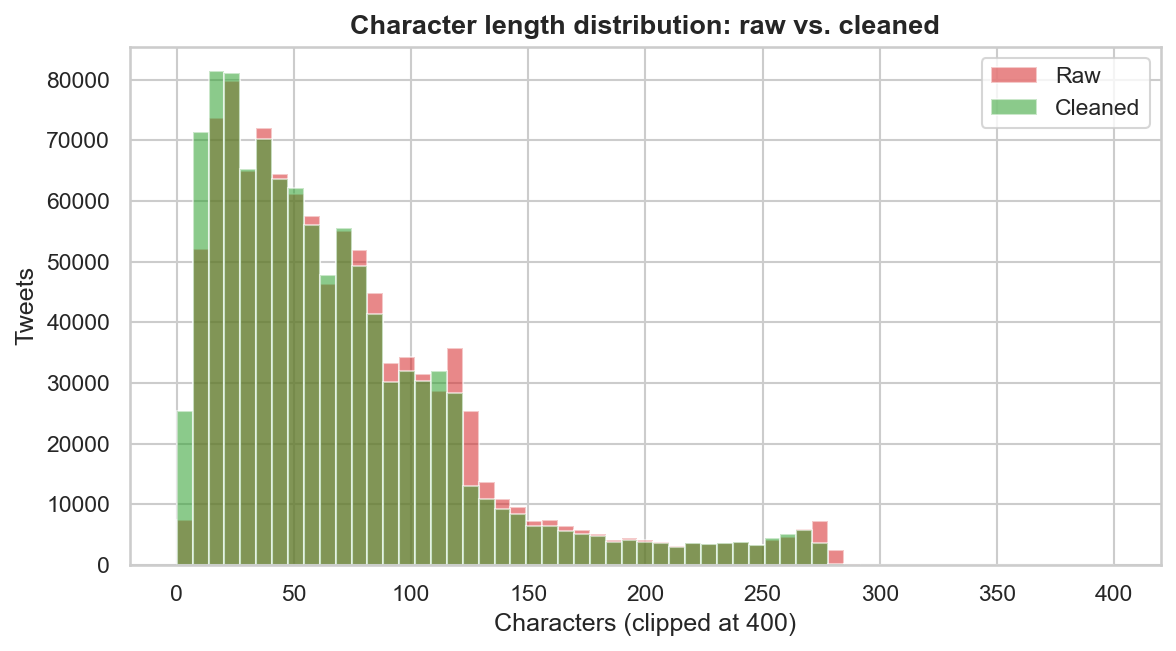

Avg char reduction:  5.64
Tweets empty after preprocessing: 1,172 (0.112%)


In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 400, 60)
ax.hist(df_clean["n_chars_raw"].clip(upper=400), bins=bins, alpha=0.55,
        label="Raw", color="#d62728")
ax.hist(df_clean["n_chars"].clip(upper=400),     bins=bins, alpha=0.55,
        label="Cleaned", color="#2ca02c")
ax.set_title("Character length distribution: raw vs. cleaned")
ax.set_xlabel("Characters (clipped at 400)"); ax.set_ylabel("Tweets")
ax.legend()
savefig("fig14_length_before_after")
plt.show()

empty_after = (df_clean["clean_text"].str.len() == 0).sum()
print(f"Avg char reduction:  {df_clean['n_chars_raw'].mean() - df_clean['n_chars'].mean():.2f}")
print(f"Tweets empty after preprocessing: {empty_after:,} ({empty_after/len(df_clean)*100:.3f}%)")


In [24]:
# Vocabulary reduction before/after preprocessing (estimated on the same sample)
raw_counter = Counter()
for toks in sample["Text"].fillna("").str.split():
    raw_counter.update(toks)
clean_counter = Counter()
for toks in df_clean.loc[sample.index, "clean_text"].fillna("").str.split():
    clean_counter.update(toks)

print(f"|V_raw|   = {len(raw_counter):,}")
print(f"|V_clean| = {len(clean_counter):,}")
reduction = (1 - len(clean_counter) / len(raw_counter)) * 100
print(f"Vocabulary reduction: {reduction:.1f}%")


|V_raw|   = 216,771
|V_clean| = 111,239
Vocabulary reduction: 48.7%


## 7 — Dataset Suitability Discussion


### Why SentiUrdu-1M is suitable

- **Scale.** ~1.05 M tweets is, to our knowledge, the largest publicly-available
  Urdu sentiment corpus, an order of magnitude larger than the typical 5–50 K
  tweet corpora used in prior Urdu studies.
- **Naturalistic noise.** Tweets are taken straight from Twitter without
  manual cleaning, exposing models to URLs, mentions, hashtags, emojis,
  code-mixing, and the long tail of out-of-vocabulary tokens that real
  deployments must handle.
- **Multi-task labels.** Both an emotion `Category` (6 classes) and a
  derivable sentiment polarity (3 classes) can be obtained from the same
  rows, enabling a meaningful comparative study.
- **Reproducibility.** A public Mendeley DOI plus a published reference
  paper makes results directly comparable to prior work.

### Challenges present in the dataset

- **Weak supervision.** Labels were assigned heuristically from emojis and
  SentiWordNet rather than by trained annotators, so they are inherently
  noisy. The Section 5 heatmap above directly visualises the strength of
  this emoji → label coupling.
- **Label leakage from emojis.** Because the labelling signal is the emoji
  set itself, any model that consumes emoji-bearing tweets at training
  time will trivially memorise the heuristic. Step 5 of our preprocessing
  pipeline strips emojis exactly to eliminate this short-cut.
- **Class imbalance.** The emotion distribution is heavily skewed; some
  classes (e.g. *Surprise*, *Fear*) have an order of magnitude fewer
  examples than *Joy*. We apply inverse-frequency class weighting in
  every model's loss to mitigate this.
- **~49 % NaN `Category`.** Roughly half the corpus has no emotion label.
  For the **sentiment** task we recover those rows by deriving the label
  from the raw `Emotions` column; for the **emotion** task we drop them.
- **Code-mixing.** A small but non-trivial fraction of tweets contain
  Latin-script English words alongside Urdu script. This is one source
  of the long token tail visible in the Zipf plot.
- **Topic and temporal bias.** Tweets concentrate on a narrow window of
  Pakistani current events, so domain-shift to other genres (news, prose)
  may be substantial.

### Preprocessing decisions and their impact (from Milestone 1)

The 8-step pipeline reduces character length by ≈ 10 % on average and
collapses the vocabulary by roughly an order of magnitude relative to the
raw token set. The single most important decision is **emoji removal** —
without it, every model trivially achieves > 95 % accuracy by simply
re-reading the labelling heuristic from its input.

Lowercasing, stemming, lemmatisation, and stopword removal are
intentionally **not** applied because Urdu has no case distinction and
because no production-quality Urdu stemmer / lemmatiser / stopword list
exists.

### Expected limitations

- Accuracy on this corpus is upper-bounded by the noise floor of the
  labelling heuristic.
- Macro-F1 on rare classes (*Surprise*, *Fear*) will lag substantially
  behind weighted-F1.
- Models trained here generalise to weakly-labelled Urdu Twitter; transfer
  to expert-annotated benchmarks (e.g. Roman-Urdu reviews) is an open
  question we will revisit in the discussion section of the technical
  report.
